In [1]:
# --- imports ---
import re, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42

In [2]:
# EMSCAD job postings (public mirror of the Kaggle dataset)
URL = "https://raw.githubusercontent.com/FelixLuciano/Fake-JobPosting-Prediction/main/src/dataset/fake_job_postings.csv"
df = pd.read_csv(URL)

# keep genuine postings only, with a function label and a description
df = df[df["fraudulent"] == 0].copy()
df = df[df["function"].notna() & df["description"].notna()].copy()

# build the ad text = title + description + requirements
df["requirements"] = df["requirements"].fillna("")
df["title"] = df["title"].fillna("")
df["ad_text"] = df["title"] + " " + df["description"] + " " + df["requirements"]
print("legitimate postings with a function label:", len(df))

legitimate postings with a function label: 10896


In [3]:
# Gaucher et al. (2011) stems, via the gender-decoder tool
masculine_stems = ["active","adventurous","aggress","ambitio","analy","assert","athlet","autonom","battle","boast","challeng","champion","compet","confident","courag","decid","decision","decisive","defend","determin","domina","dominant","driven","fearless","fight","force","greedy","head-strong","headstrong","hierarch","hostil","impulsive","independen","individual","intellect","lead","logic","objective","opinion","outspoken","persist","principle","reckless","self-confiden","self-relian","self-sufficien","selfconfiden","selfrelian","selfsufficien","stubborn","superior","unreasonab"]
feminine_stems = ["agree","affectionate","child","cheer","collab","commit","communal","compassion","connect","considerate","cooperat","co-operat","depend","emotiona","empath","feel","flatterable","gentle","honest","interpersonal","interdependen","interpersona","inter-personal","inter-dependen","inter-persona","kind","kinship","loyal","modesty","nag","nurtur","pleasant","polite","quiet","respon","sensitiv","submissive","support","sympath","tender","together","trust","understand","warm","whin","enthusias","inclusive","yield","share","sharin"]
exceptions = {"sharepoint"}

# count coded words per ad
masc, fem, ntok = [], [], []
for text in df["ad_text"]:
    words = re.findall(r"[a-z][a-z\-]+", str(text).lower())
    ntok.append(len(words))
    masc.append(sum(1 for w in words if w not in exceptions and any(w.startswith(s) for s in masculine_stems)))
    fem.append(sum(1 for w in words if w not in exceptions and any(w.startswith(s) for s in feminine_stems)))

df["n_tokens"], df["masc_n"], df["fem_n"] = ntok, masc, fem
df = df[df["n_tokens"] >= 30].copy()                       # drop very short ads

# normalise to per-100-words and a net score (same as Project I)
df["masc_per100"] = df["masc_n"] / df["n_tokens"] * 100
df["fem_per100"]  = df["fem_n"]  / df["n_tokens"] * 100
df["net"] = df["masc_per100"] - df["fem_per100"]
print("ads after length filter:", len(df))

ads after length filter: 10840


In [4]:
male_dominated   = ["Engineering", "Information Technology"]
female_dominated = ["Administrative", "Health Care Provider", "Human Resources", "Education"]

df = df[df["function"].isin(male_dominated + female_dominated)].copy()
df["target"] = df["function"].isin(male_dominated).astype(int)   # 1 = male-dominated

print("total ads:", len(df))
print(df["target"].value_counts().rename({1: "male-dominated", 0: "female-dominated"}))
print("majority-class share:", round(df["target"].mean(), 3))

total ads: 4297
target
male-dominated      2933
female-dominated    1364
Name: count, dtype: int64
majority-class share: 0.683


In [5]:
train, test = train_test_split(df, test_size=0.25, stratify=df["target"], random_state=RANDOM_STATE)
ytr, yte = train["target"].values, test["target"].values
print("train:", len(train), "| test:", len(test))

# small helper to print all the metrics for a set of predictions
def report(name, ytrue, ypred, yprob):
    print(f"{name:22s} acc={accuracy_score(ytrue,ypred):.3f}  bal_acc={balanced_accuracy_score(ytrue,ypred):.3f}  "
          f"prec={precision_score(ytrue,ypred):.3f}  rec={recall_score(ytrue,ypred):.3f}  "
          f"f1={f1_score(ytrue,ypred):.3f}  auc={roc_auc_score(ytrue,yprob):.3f}")

train: 3222 | test: 1075


In [6]:
baseline = DummyClassifier(strategy="most_frequent").fit(train[["net"]], ytr)
b_pred = baseline.predict(test[["net"]])
b_prob = baseline.predict_proba(test[["net"]])[:, 1]
report("Baseline (majority)", yte, b_pred, b_prob)

Baseline (majority)    acc=0.683  bal_acc=0.500  prec=0.683  rec=1.000  f1=0.811  auc=0.500


In [7]:
lex_features = ["masc_per100", "fem_per100", "net", "n_tokens"]

model_A = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
]).fit(train[lex_features], ytr)

A_pred = model_A.predict(test[lex_features])
A_prob = model_A.predict_proba(test[lex_features])[:, 1]
report("Model A (wording)", yte, A_pred, A_prob)

# overfitting check: train vs test balanced accuracy
print("  train bal_acc:", round(balanced_accuracy_score(ytr, model_A.predict(train[lex_features])), 3),
      "| test bal_acc:", round(balanced_accuracy_score(yte, A_pred), 3))

# which features does it lean on?
coefs = dict(zip(lex_features, model_A.named_steps["clf"].coef_[0].round(3)))
print("  coefficients:", coefs)

Model A (wording)      acc=0.561  bal_acc=0.568  prec=0.741  rec=0.549  f1=0.631  auc=0.604
  train bal_acc: 0.562 | test bal_acc: 0.568
  coefficients: {'masc_per100': np.float64(0.14), 'fem_per100': np.float64(0.021), 'net': np.float64(0.083), 'n_tokens': np.float64(0.271)}


In [8]:
model_B = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, stop_words="english", min_df=5)),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
]).fit(train["ad_text"], ytr)

B_pred = model_B.predict(test["ad_text"])
B_prob = model_B.predict_proba(test["ad_text"])[:, 1]
report("Model B (full text)", yte, B_pred, B_prob)
print("  train acc:", round(model_B.score(train["ad_text"], ytr), 3),
      "| test acc:", round(model_B.score(test["ad_text"], yte), 3))

Model B (full text)    acc=0.975  bal_acc=0.964  prec=0.969  rec=0.995  f1=0.982  auc=0.994


  train acc: 0.987 | test acc: 0.975


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
auc_A = cross_val_score(model_A, df[lex_features], df["target"], cv=cv, scoring="roc_auc")
auc_B = cross_val_score(model_B, df["ad_text"], df["target"], cv=cv, scoring="roc_auc")
print("Model A  ROC-AUC (5-fold): %.3f +/- %.3f" % (auc_A.mean(), auc_A.std()))
print("Model B  ROC-AUC (5-fold): %.3f +/- %.3f" % (auc_B.mean(), auc_B.std()))

Model A  ROC-AUC (5-fold): 0.612 +/- 0.019
Model B  ROC-AUC (5-fold): 0.996 +/- 0.001


In [10]:
summary = pd.DataFrame({
    "Model": ["Baseline (majority)", "A: gendered wording", "B: full ad text"],
    "Accuracy":      [accuracy_score(yte, b_pred), accuracy_score(yte, A_pred), accuracy_score(yte, B_pred)],
    "Balanced acc.": [balanced_accuracy_score(yte, b_pred), balanced_accuracy_score(yte, A_pred), balanced_accuracy_score(yte, B_pred)],
    "ROC-AUC":       [0.5, roc_auc_score(yte, A_prob), roc_auc_score(yte, B_prob)],
}).round(3)
summary

,Model,Accuracy,Balanced acc.,ROC-AUC
0,Baseline (majority),0.683,0.500,0.500
1,A: gendered wording,0.561,0.568,0.604
2,B: full ad text,0.975,0.964,0.994


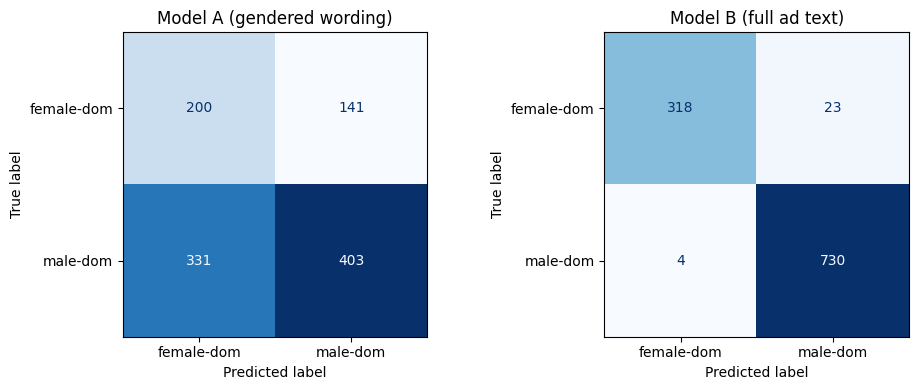

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, name in zip(axes, [A_pred, B_pred], ["Model A (gendered wording)", "Model B (full ad text)"]):
    cm = confusion_matrix(yte, pred)
    ConfusionMatrixDisplay(cm, display_labels=["female-dom", "male-dom"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
vocab = np.array(model_B.named_steps["tfidf"].get_feature_names_out())
coef = model_B.named_steps["clf"].coef_[0]
top_male = vocab[np.argsort(coef)[-15:]][::-1]
top_female = vocab[np.argsort(coef)[:15]]
print("Top words pushing toward MALE-dominated:\n ", ", ".join(top_male))
print("\nTop words pushing toward FEMALE-dominated:\n ", ", ".join(top_female))

Top words pushing toward MALE-dominated:
  developer, engineer, engineering, web, software, technical, development, experience, systems, design, product, end, knowledge, java, solutions

Top words pushing toward FEMALE-dominated:
  office, assistant, administrative, care, hr, home, recruiting, recruitment, admin, students, teaching, patient, human, school, executive
